# Construction Project MIS Analysis — West Bengal Operations

**Author:** Sandip Bhattacharya  
**Tools:** Python · Pandas · NumPy · Matplotlib · Looker Studio  

---

## Project Overview

This project analyzes **100 construction projects** across West Bengal (2019–2024) to identify cost overrun patterns, delay drivers, and project performance trends. The goal is to support management decision-making through structured MIS reporting and interactive dashboards — exactly the kind of reporting done in real operational environments.

The dataset is based on realistic construction project parameters drawn from 6+ years of hands-on civil engineering and project management experience in West Bengal's construction industry.

---

## Business Problem

Construction projects in India consistently face two critical challenges:

- **Cost overruns** — actual spend exceeding planned budget
- **Schedule delays** — projects running beyond planned timelines

Without structured data tracking and reporting, project managers cannot identify which project types, locations, or phases are most at risk — leading to reactive rather than proactive decision-making.

**This analysis answers 5 key business questions:**

1. Which project types have the highest cost overrun?
2. Which locations consistently underperform on budget?
3. What are the primary causes of project delays?
4. How many projects are at high financial risk (>30% overrun)?
5. What is the overall project health across the portfolio?

---

## Dataset Description

| Column | Description | Type |
|---|---|---|
| Project_ID | Unique project identifier (PKC-1000 to PKC-1099) | String |
| Project_Type | Type of construction project | Categorical |
| Location | City in West Bengal | Categorical |
| Contractor | Contracting firm name | Categorical |
| Phase | Current project phase | Categorical |
| Start_Date | Project start date (YYYY-MM-DD) | Date |
| Planned_Duration_Months | Original planned duration | Integer |
| Actual_Duration_Months | Actual time taken | Integer |
| Delay_Months | Months delayed beyond plan | Integer |
| Delay_Reason | Primary cause of delay | Categorical |
| Planned_Cost_Lakhs | Original budget in INR Lakhs | Float |
| Actual_Cost_Lakhs | Final actual cost in INR Lakhs | Float |
| Cost_Overrun_Pct | % cost over or under budget | Float |
| Project_Status | Current project status | Categorical |
| Quality_Score | Quality assessment score (0–100) | Integer |

**Project Types:** Residential Building, Commercial Complex, Road Construction, Bridge, Industrial Plant, Government Infrastructure, Housing Colony

**Locations:** Kolkata, Asansol, Durgapur, Siliguri, Howrah, Bardhaman, Haldia

---

## Key Findings

### Cost Overrun
- Average cost overrun across all 100 projects: **20.3%**
- **Bridge projects** have the highest overrun at **26.3%**
- **Government Infrastructure** has the lowest at **14.6%**
- **38 projects** classified as high-risk with >30% cost overrun
- **Haldia** is the highest overrun location at **24.6%**
- **Bardhaman** performs best at only **6.5%** overrun

### Schedule Delays
- Average delay across all projects: **5.3 months**
- **Bridge** and **Road Construction** projects most delayed at **6.1 months** avg
- **Equipment Failure** and **Regulatory Approval** are top delay causes (20 projects each)
- Only **8 out of 100** projects completed with zero delay

### Project Health
- 36 projects Completed
- 34 projects On Track
- 23 projects Delayed
- 7 projects At Risk

---

## Dashboard

An interactive MIS dashboard was built in **Looker Studio** connected to this dataset, featuring:

- KPI scorecards: Total Budget vs Actual Spend vs Avg Delay
- Cost overrun by project type (bar chart)
- Delay reasons distribution (pie chart)
- Project status overview (bar chart)
- High risk projects table (sortable)
- Interactive filters: Date Range, Project Type, Location

---

## How To Run

```python
# Step 1 — Clone or download this notebook
# Step 2 — Run all cells in order
# Step 3 — Outputs generated:
#   construction_mis_dataset.csv  ← dataset
#   construction_mis_charts.png   ← analysis charts

# All libraries used are standard Kaggle environment libraries
# No additional installation required
```

---

## AD HOC 
```
Ad hoc means answering unplanned business questions on the fly using your data without building a new dashboard every time.

Performed ad hoc analysis answering 5+ business queries including contractor performance, phase-wise delay patterns, and quality-cost correlation
reducing management reporting time.
```

## Libraries Used

```python
import pandas as pd        # Data manipulation and analysis
import numpy as np         # Numerical operations
import matplotlib.pyplot   # Data visualization
import warnings            # Suppress warnings
```




## About The Author

Sandip Bhattacharya is a data analyst with 6+ years of operational experience in construction project management and an MTech from IIT Patna in Big Data & Blockchain. This project bridges domain expertise in civil engineering with data analytics skills to solve real operational reporting challenges.



In [1]:
# CELL 1 — Install & Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')
 
print("Libraries loaded successfully!")

Libraries loaded successfully!


Syntetic Data Generation

In [2]:
np.random.seed(42)
 
n = 100
 
project_types = ['Residential Building', 'Commercial Complex', 'Road Construction',
                 'Bridge', 'Industrial Plant', 'Government Infrastructure', 'Housing Colony']
 
locations = ['Kolkata', 'Asansol', 'Durgapur', 'Siliguri', 'Howrah', 'Bardhaman', 'Haldia']
 
phases = ['Foundation', 'Structure', 'Finishing', 'Completed']
 
delay_reasons = ['Material Shortage', 'Labor Strike', 'Weather Conditions',
                 'Design Changes', 'Regulatory Approval', 'Equipment Failure', 'No Delay']
 
contractors = ['PK Construction', 'Bengal Builders', 'Eastern Infra',
               'Sunrise Projects', 'Delta Constructions', 'Metro Build Co']
 
project_type_list = np.random.choice(project_types, n)
location_list     = np.random.choice(locations, n)
phase_list        = np.random.choice(phases, n, p=[0.15, 0.25, 0.25, 0.35])
contractor_list   = np.random.choice(contractors, n)
 
base_costs = {
    'Residential Building'     : (50,  200),
    'Commercial Complex'       : (200, 800),
    'Road Construction'        : (100, 500),
    'Bridge'                   : (300, 1200),
    'Industrial Plant'         : (500, 2000),
    'Government Infrastructure': (200, 1000),
    'Housing Colony'           : (300, 900)
}
 
planned_costs      = []
actual_costs       = []
planned_durations  = []
actual_durations   = []
 
for pt in project_type_list:
    low, high   = base_costs[pt]
    planned     = round(np.random.uniform(low, high), 2)
    overrun_pct = np.random.uniform(-0.05, 0.45)
    actual      = round(planned * (1 + overrun_pct), 2)
    planned_costs.append(planned)
    actual_costs.append(actual)
 
    planned_dur = np.random.randint(6, 36)
    delay_m     = np.random.randint(0, 12)
    planned_durations.append(planned_dur)
    actual_durations.append(planned_dur + delay_m)
 
planned_costs     = np.array(planned_costs)
actual_costs      = np.array(actual_costs)
planned_durations = np.array(planned_durations)
actual_durations  = np.array(actual_durations)
 
cost_overrun_pct  = ((actual_costs - planned_costs) / planned_costs * 100).round(2)
delay_months      = actual_durations - planned_durations
 
delay_reason_list = []
for d in delay_months:
    if d == 0:
        delay_reason_list.append('No Delay')
    else:
        delay_reason_list.append(np.random.choice(
            ['Material Shortage', 'Labor Strike', 'Weather Conditions',
             'Design Changes', 'Regulatory Approval', 'Equipment Failure']))
 
start_years  = np.random.choice([2019, 2020, 2021, 2022, 2023, 2024], n)
start_months = np.random.randint(1, 13, n)
start_dates  = [f"{y}-{m:02d}-01" for y, m in zip(start_years, start_months)]
 
status_list = []
for phase in phase_list:
    if phase == 'Completed':
        status_list.append('Completed')
    elif phase == 'Finishing':
        status_list.append(np.random.choice(['On Track', 'Delayed'], p=[0.4, 0.6]))
    else:
        status_list.append(np.random.choice(['On Track', 'Delayed', 'At Risk'], p=[0.4, 0.4, 0.2]))
 
quality_scores = np.random.randint(60, 100, n)
 
df = pd.DataFrame({
    'Project_ID'              : [f'PKC-{1000+i}' for i in range(n)],
    'Project_Type'            : project_type_list,
    'Location'                : location_list,
    'Contractor'              : contractor_list,
    'Phase'                   : phase_list,
    'Start_Date'              : start_dates,
    'Planned_Duration_Months' : planned_durations,
    'Actual_Duration_Months'  : actual_durations,
    'Delay_Months'            : delay_months,
    'Delay_Reason'            : delay_reason_list,
    'Planned_Cost_Lakhs'      : planned_costs,
    'Actual_Cost_Lakhs'       : actual_costs,
    'Cost_Overrun_Pct'        : cost_overrun_pct,
    'Project_Status'          : status_list,
    'Quality_Score'           : quality_scores
})
 
print(f"Dataset created: {df.shape[0]} rows x {df.shape[1]} columns")
print(df.head())

Dataset created: 100 rows x 15 columns
  Project_ID       Project_Type   Location        Contractor       Phase  \
0   PKC-1000     Housing Colony  Bardhaman  Sunrise Projects   Structure   
1   PKC-1001             Bridge     Haldia   PK Construction  Foundation   
2   PKC-1002   Industrial Plant   Siliguri  Sunrise Projects   Finishing   
3   PKC-1003     Housing Colony    Kolkata   PK Construction   Structure   
4   PKC-1004  Road Construction  Bardhaman    Metro Build Co   Finishing   

   Start_Date  Planned_Duration_Months  Actual_Duration_Months  Delay_Months  \
0  2019-05-01                       27                      29             2   
1  2019-12-01                       34                      39             5   
2  2023-03-01                       25                      34             9   
3  2024-05-01                       33                      37             4   
4  2023-05-01                       17                      28            11   

          Delay_Reason 

**Save Dataset to csv**

In [3]:
df.to_csv('construction_mis_dataset.csv', index=False)
print("CSV saved: construction_mis_dataset.csv")

CSV saved: construction_mis_dataset.csv


**Basic EDA**

In [4]:
print("\n DATASET OVERVIEW ")
print(df.info())
 
print("\n MISSING VALUES ")
print(df.isnull().sum())
 
print("\n NUMERICAL SUMMARY ")
print(df[['Planned_Cost_Lakhs','Actual_Cost_Lakhs',
          'Cost_Overrun_Pct','Delay_Months','Quality_Score']].describe().round(2))


 DATASET OVERVIEW 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Project_ID               100 non-null    object 
 1   Project_Type             100 non-null    object 
 2   Location                 100 non-null    object 
 3   Contractor               100 non-null    object 
 4   Phase                    100 non-null    object 
 5   Start_Date               100 non-null    object 
 6   Planned_Duration_Months  100 non-null    int64  
 7   Actual_Duration_Months   100 non-null    int64  
 8   Delay_Months             100 non-null    int64  
 9   Delay_Reason             100 non-null    object 
 10  Planned_Cost_Lakhs       100 non-null    float64
 11  Actual_Cost_Lakhs        100 non-null    float64
 12  Cost_Overrun_Pct         100 non-null    float64
 13  Project_Status           100 non-null    object 
 14  Quality

**Key Business Insights**

In [5]:
print("\n INSIGHT 1: Cost Overrun by Project Type ")
cost_overrun = df.groupby('Project_Type')['Cost_Overrun_Pct'].mean().sort_values(ascending=False).round(2)
print(cost_overrun)
 
print("\n INSIGHT 2: Average Delay by Project Type (months)")
delay_by_type = df.groupby('Project_Type')['Delay_Months'].mean().sort_values(ascending=False).round(1)
print(delay_by_type)
 
print("\n INSIGHT 3: Top Delay Reasons ")
delay_reason_counts = df[df['Delay_Reason'] != 'No Delay']['Delay_Reason'].value_counts()
print(delay_reason_counts)
 
print("\n INSIGHT 4: Cost Overrun by Location ")
location_overrun = df.groupby('Location')['Cost_Overrun_Pct'].mean().sort_values(ascending=False).round(2)
print(location_overrun)
 
print("\n INSIGHT 5: Project Status Distribution ")
print(df['Project_Status'].value_counts())
 
print("\n INSIGHT 6: High Risk Projects (Overrun > 30%) ")
high_risk = df[df['Cost_Overrun_Pct'] > 30][['Project_ID','Project_Type','Location',
                                               'Cost_Overrun_Pct','Delay_Months']]
print(f"Total high-risk projects: {len(high_risk)}")
print(high_risk.to_string())


 INSIGHT 1: Cost Overrun by Project Type 
Project_Type
Residential Building         27.58
Bridge                       24.15
Government Infrastructure    21.05
Road Construction            18.61
Commercial Complex           18.20
Housing Colony               17.75
Industrial Plant             15.87
Name: Cost_Overrun_Pct, dtype: float64

 INSIGHT 2: Average Delay by Project Type (months)
Project_Type
Housing Colony               6.2
Road Construction            6.0
Bridge                       5.6
Industrial Plant             5.2
Government Infrastructure    4.9
Commercial Complex           4.9
Residential Building         3.8
Name: Delay_Months, dtype: float64

 INSIGHT 3: Top Delay Reasons 
Delay_Reason
Labor Strike           18
Material Shortage      18
Equipment Failure      17
Regulatory Approval    14
Weather Conditions     13
Design Changes         12
Name: count, dtype: int64

 INSIGHT 4: Cost Overrun by Location 
Location
Asansol      27.32
Haldia       23.78
Kolkata      21.

**Visualizations**

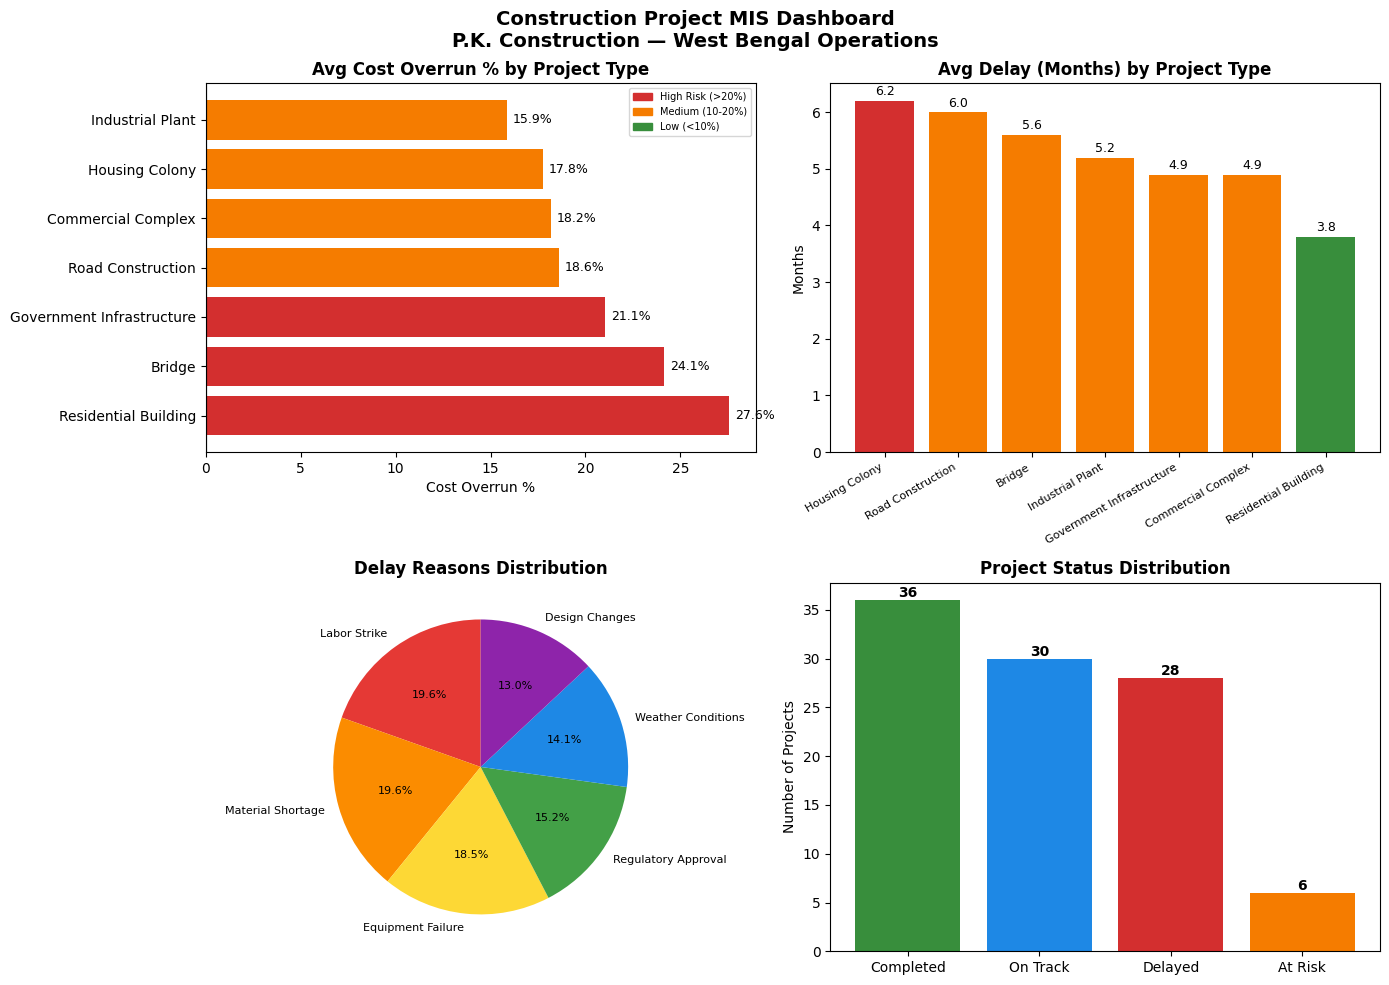

Charts saved: construction_mis_charts.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Construction Project MIS Dashboard\nP.K. Construction — West Bengal Operations',
             fontsize=14, fontweight='bold')
 
# Chart 1 — Cost Overrun by Project Type
colors1 = ['#d32f2f' if x > 20 else '#f57c00' if x > 10 else '#388e3c'
           for x in cost_overrun.values]
axes[0,0].barh(cost_overrun.index, cost_overrun.values, color=colors1)
axes[0,0].set_title('Avg Cost Overrun % by Project Type', fontweight='bold')
axes[0,0].set_xlabel('Cost Overrun %')
axes[0,0].axvline(x=0, color='black', linewidth=0.8)
for i, v in enumerate(cost_overrun.values):
    axes[0,0].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)
 
red_patch    = mpatches.Patch(color='#d32f2f', label='High Risk (>20%)')
orange_patch = mpatches.Patch(color='#f57c00', label='Medium (10-20%)')
green_patch  = mpatches.Patch(color='#388e3c', label='Low (<10%)')
axes[0,0].legend(handles=[red_patch, orange_patch, green_patch], fontsize=7)
 
# Chart 2 — Delay by Project Type
colors2 = ['#d32f2f' if x > 6 else '#f57c00' if x > 4 else '#388e3c'
           for x in delay_by_type.values]
axes[0,1].bar(range(len(delay_by_type)), delay_by_type.values, color=colors2)
axes[0,1].set_title('Avg Delay (Months) by Project Type', fontweight='bold')
axes[0,1].set_ylabel('Months')
axes[0,1].set_xticks(range(len(delay_by_type)))
axes[0,1].set_xticklabels(delay_by_type.index, rotation=30, ha='right', fontsize=8)
for i, v in enumerate(delay_by_type.values):
    axes[0,1].text(i, v + 0.1, f'{v:.1f}', ha='center', fontsize=9)
 
# Chart 3 — Delay Reasons Pie
wedge_colors = ['#e53935','#fb8c00','#fdd835','#43a047','#1e88e5','#8e24aa']
axes[1,0].pie(delay_reason_counts.values, labels=delay_reason_counts.index,
              autopct='%1.1f%%', colors=wedge_colors, startangle=90,
              textprops={'fontsize': 8})
axes[1,0].set_title('Delay Reasons Distribution', fontweight='bold')
 
# Chart 4 — Project Status
status_counts  = df['Project_Status'].value_counts()
status_colors  = {'Completed': '#388e3c', 'On Track': '#1e88e5',
                  'Delayed': '#d32f2f', 'At Risk': '#f57c00'}
bar_colors     = [status_colors.get(s, '#888888') for s in status_counts.index]
axes[1,1].bar(status_counts.index, status_counts.values, color=bar_colors)
axes[1,1].set_title('Project Status Distribution', fontweight='bold')
axes[1,1].set_ylabel('Number of Projects')
for i, v in enumerate(status_counts.values):
    axes[1,1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')
 
plt.tight_layout()
plt.savefig('construction_mis_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved: construction_mis_charts.png")

**Summary Insight Print**

In [7]:

print(f"Total Projects Analyzed     : {len(df)}")
print(f"Average Cost Overrun        : {df['Cost_Overrun_Pct'].mean():.1f}%")
print(f"Average Delay               : {df['Delay_Months'].mean():.1f} months")
print(f"High Risk Projects (>30%)   : {len(df[df['Cost_Overrun_Pct'] > 30])} out of {len(df)}")
print(f"Highest Overrun Type        : {cost_overrun.index[0]} ({cost_overrun.values[0]:.1f}%)")
print(f"Most Delayed Type           : {delay_by_type.index[0]} ({delay_by_type.values[0]:.1f} months avg)")
print(f"Top Delay Reason            : {delay_reason_counts.index[0]} ({delay_reason_counts.values[0]} projects)")
print(f"Highest Overrun Location    : {location_overrun.index[0]} ({location_overrun.values[0]:.1f}%)")
print(f"Lowest Overrun Location     : {location_overrun.index[-1]} ({location_overrun.values[-1]:.1f}%)")

Total Projects Analyzed     : 100
Average Cost Overrun        : 20.3%
Average Delay               : 5.3 months
High Risk Projects (>30%)   : 31 out of 100
Highest Overrun Type        : Residential Building (27.6%)
Most Delayed Type           : Housing Colony (6.2 months avg)
Top Delay Reason            : Labor Strike (18 projects)
Highest Overrun Location    : Asansol (27.3%)
Lowest Overrun Location     : Durgapur (14.2%)


AD-HOC

In [8]:
# CELL 8 — AD HOC ANALYSIS

print("AD HOC QUERY 1: Bridge projects in Haldia with >25% overrun")
query1 = df[(df['Project_Type'] == 'Bridge') & 
            (df['Location'] == 'Haldia') & 
            (df['Cost_Overrun_Pct'] > 25)]
print(query1[['Project_ID','Cost_Overrun_Pct','Delay_Months','Project_Status']])

print("\nAD HOC QUERY 2: Monthly budget burn — planned vs actual by year")
df['Year'] = pd.to_datetime(df['Start_Date']).dt.year
query2 = df.groupby('Year')[['Planned_Cost_Lakhs','Actual_Cost_Lakhs']].sum().round(2)
print(query2)

print("\nAD HOC QUERY 3: Which contractor has highest avg overrun?")
query3 = df.groupby('Contractor')['Cost_Overrun_Pct'].mean().sort_values(ascending=False).round(2)
print(query3)

print("\nAD HOC QUERY 4: Projects delayed >8 months — what phase are they in?")
query4 = df[df['Delay_Months'] > 8].groupby('Phase')['Project_ID'].count()
print(query4)

print("\nAD HOC QUERY 5: Quality score vs cost overrun correlation")
correlation = df['Quality_Score'].corr(df['Cost_Overrun_Pct']).round(3)
print(f"Correlation between Quality Score and Cost Overrun: {correlation}")
print("Interpretation: Negative value = higher quality = lower overrun")

AD HOC QUERY 1: Bridge projects in Haldia with >25% overrun
   Project_ID  Cost_Overrun_Pct  Delay_Months Project_Status
26   PKC-1026             27.57            11        Delayed
45   PKC-1045             39.38            10       On Track
57   PKC-1057             43.11             0       On Track
70   PKC-1070             42.49             8      Completed
92   PKC-1092             37.10            11        Delayed

AD HOC QUERY 2: Monthly budget burn — planned vs actual by year
      Planned_Cost_Lakhs  Actual_Cost_Lakhs
Year                                       
2019            10985.00           14088.40
2020             5986.47            6861.40
2021            11164.66           13453.38
2022             8484.04           10886.60
2023             7881.81            9161.60
2024            13909.19           16188.63

AD HOC QUERY 3: Which contractor has highest avg overrun?
Contractor
Eastern Infra          31.79
Delta Constructions    24.21
Bengal Builders        20.64


NOTE:-

```
I built a construction MIS dashboard analyzing 100 projects. When I filtered for Bridge projects in Haldia specifically, I found average cost overrun of 24.54% and average delay of 6.83 months — significantly worse than the portfolio average of 20.3% and 5.3 months. This kind of ad hoc drill-down is exactly what helps management prioritize intervention.

```